In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SED results

In [29]:
data = pd.read_csv('/home/yuan/JWST/CentralDogma/6_Heresy_/SEDresult.csv')
data = data.loc[data['bdbest']==1]
SB = data.loc[data['type']=='sb']
AT = data.loc[data['type']=='at']
LZ = data.loc[data['type']=='lz']

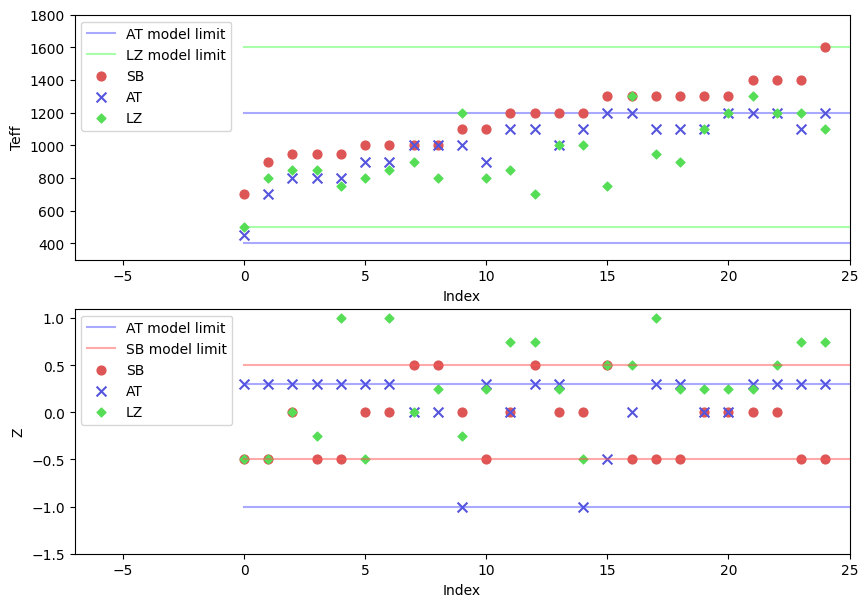

In [30]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

Trange = [300, 1800]
Zrange = [-1.5, 1.1]
index = np.arange(len(SB))

ax = axs[0]
ax.plot([0, 25], [1200, 1200], c='#5555FF', alpha=0.5, label='AT model limit')
ax.plot([0, 25], [400, 400], c='#5555FF', alpha=0.5)
ax.plot([0, 25], [1600, 1600], c='#55FF55', alpha=0.5, label='LZ model limit')
ax.plot([0, 25], [500, 500], c='#55FF55', alpha=0.5)
ax.scatter(index, SB['Teff'], c='#DD5555', marker='o', s=40, label='SB', zorder=10)
ax.scatter(index, AT['Teff'], c='#5555DD', marker='x', s=50, label='AT', zorder=10)
ax.scatter(index, LZ['Teff'], c='#55DD55', marker='D', s=20, label='LZ', zorder=10)
ax.set_ylim(Trange)
ax.set_ylabel('Teff')

ax = axs[1]
ax.plot([0, 25], [-1, -1], c='#5555FF', alpha=0.5, label='AT model limit')
ax.plot([0, 25], [0.3, 0.3], c='#5555FF', alpha=0.5)
ax.plot([0, 25], [0.5, 0.5], c='#FF5555', alpha=0.5, label='SB model limit')
ax.plot([0, 25], [-0.5, -0.5], c='#FF5555', alpha=0.5)
ax.scatter(index, SB['logZ'], c='#DD5555', marker='o', s=40, label='SB')
ax.scatter(index, AT['logZ'], c='#5555DD', marker='x', s=50, label='AT')
ax.scatter(index, LZ['logZ'], c='#55DD55', marker='D', s=20, label='LZ')
ax.set_ylim(Zrange)
ax.set_ylabel('Z')

for ax in axs:
    ax.set_xlim(-7, 25)
    ax.set_xlabel('Index')
    ax.legend(loc='upper left')
    
plt.show()

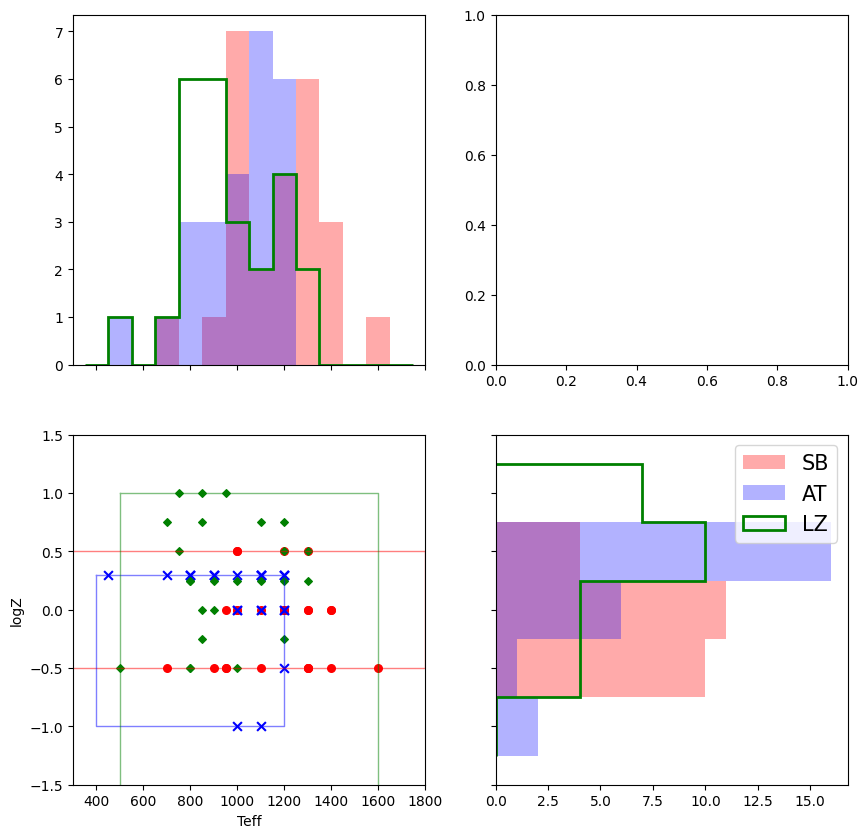

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

Trange = [300, 1800]
Zrange = [-1.5, 1.5]
Tbins = np.linspace(Trange[0]+50, Trange[1]-50, 15)

ax = axs[0, 0]
ax.hist(SB['Teff'], bins=Tbins, histtype='bar', color='#FFAAAA', label='SB')
ax.hist(AT['Teff'], bins=Tbins, histtype='bar', color='b', label='AT', alpha=0.3)
ax.hist(LZ['Teff'], bins=Tbins, histtype='step', color='g', label='LZ', lw=2)

ax.set_xlim(Trange)
ax.set_xticklabels([])

ax = axs[1, 1]
ax.hist(SB['logZ'], bins=[-0.75, -0.25, 0.25, 0.75],
        histtype='bar', color='#FFAAAA', label='SB', lw=2, orientation='horizontal')
ax.hist(AT['logZ'], bins=[-1.25, -0.75, -0.25, 0.25, 0.75],
        histtype='bar', color='b', label='AT', alpha=0.3, orientation='horizontal')
ax.hist(LZ['logZ'], bins=[-1.25, -0.75, -0.25, 0.25, 0.75, 1.25],
        histtype='step', color='g', label='LZ', lw=2, orientation='horizontal')

ax.legend(loc='upper right', fontsize=15)
ax.set_ylim(Zrange)
ax.set_yticklabels([])

ax = axs[1, 0]
ax.plot([200, 1800, 1800, 200, 200], [0.5, 0.5, -0.5, -0.5, 0.5],
        color='r', lw=1, alpha=0.5)
ax.plot([400, 1200, 1200, 400, 400], [0.3, 0.3, -1, -1, 0.3],
        color='b', lw=1, alpha=0.5)
ax.plot([500, 1600, 1600, 500, 500], [1, 1, -2.5, -2.5, 1],
        color='g', lw=1, alpha=0.5)
ax.scatter(SB['Teff'], SB['logZ'], color='r', label='SB', s=30)
ax.scatter(AT['Teff'], AT['logZ'], color='b', label='AT', s=40, marker='x')
ax.scatter(LZ['Teff'], LZ['logZ'], color='g', label='LZ', s=15, marker='D')

ax.set_xlim(Trange)
ax.set_ylim(Zrange)
ax.set_xlabel('Teff')
ax.set_ylabel('logZ')

plt.show()

# MCMC results

In [4]:
SB_data = pd.read_csv('/home/yuan/JWST/BD_mcmc/result2/SB_results.csv')
AT_data = pd.read_csv('/home/yuan/JWST/BD_mcmc/result2/AT_results.csv')
LZ_data = pd.read_csv('/home/yuan/JWST/BD_mcmc/result2/LZ_results.csv')

In [19]:
SB_data.loc[(SB_data['T_peak']<1350)&(SB_data['T_peak']>1200)]

,ID,T_peak,logg_peak,Z_peak,d_peak,Teff16,Teff50,Teff84,logg16,logg50,logg84,Z16,Z50,Z84,d16,d50,d84
1,2302,1208.0,4.8,0.0,1985.0,1149.2,1195.1,1235.2,4.31,4.74,5.11,-0.41,-0.11,0.23,1771.0,2051.0,2400.0
3,2304,1222.5,5.1,0.0,469.5,1200.7,1219.1,1222.5,4.97,5.07,5.12,-0.03,0.00,0.04,465.0,468.0,494.0
5,2307,1287.5,5.3,-0.5,1500.0,1248.6,1285.5,1318.7,4.87,5.22,5.47,-0.50,-0.21,0.16,1437.0,1639.0,1915.0
6,2308,1212.5,4.5,0.0,922.2,1203.3,1213.6,1221.2,4.39,4.47,4.54,-0.03,0.01,0.05,908.0,932.0,953.0
8,2310,1302.5,5.5,-0.6,1537.5,1275.3,1299.2,1322.1,5.25,5.45,5.55,-0.55,-0.42,-0.14,1475.0,1559.0,1683.0
12,2316,1336.2,5.3,-0.5,1525.0,1289.4,1328.1,1359.8,4.79,5.18,5.44,-0.47,-0.14,0.31,1340.0,1548.0,1845.0
15,2319,1330.0,5.6,-0.5,2082.5,1272.4,1319.6,1367.1,4.77,5.21,5.48,-0.47,-0.13,0.37,1951.0,2224.0,2671.0
16,2320,1218.8,5.5,-0.5,1237.5,1193.7,1219.9,1241.5,5.22,5.44,5.55,-0.53,-0.30,0.00,1178.0,1244.0,1355.0
21,12016,1337.5,3.6,0.5,4057.5,1263.8,1330.0,1400.6,3.27,3.71,4.21,-0.38,0.06,0.43,3477.0,4160.0,4890.0
23,12051,1322.5,4.0,-0.1,1390.0,1312.7,1322.7,1331.2,3.96,4.05,4.14,-0.19,-0.08,0.01,1331.0,1389.0,1444.0


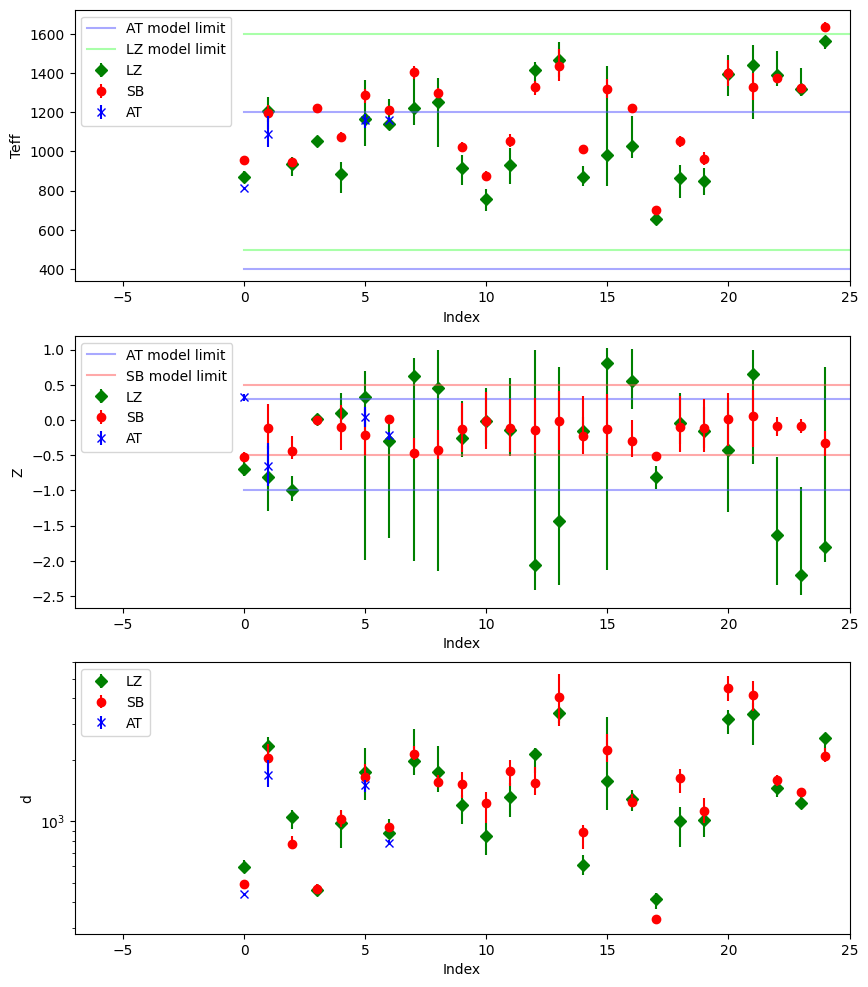

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

Trange = [300, 1800]
Zrange = [-2.6, 1.1]
Drange = [0, 6000]
params = ['Teff', 'Z', 'd']
pararange = [Trange, Zrange, Drange]
index = np.arange(len(SB_data))

ax = axs[0]
ax.plot([0, 25], [1200, 1200], c='#5555FF', alpha=0.5, label='AT model limit')
ax.plot([0, 25], [400, 400], c='#5555FF', alpha=0.5)
ax.plot([0, 25], [1600, 1600], c='#55FF55', alpha=0.5, label='LZ model limit')
ax.plot([0, 25], [500, 500], c='#55FF55', alpha=0.5)

ax = axs[1]
ax.plot([0, 25], [-1, -1], c='#5555FF', alpha=0.5, label='AT model limit')
ax.plot([0, 25], [0.3, 0.3], c='#5555FF', alpha=0.5)
ax.plot([0, 25], [0.5, 0.5], c='#FF5555', alpha=0.5, label='SB model limit')
ax.plot([0, 25], [-0.5, -0.5], c='#FF5555', alpha=0.5)

for i in range(3):
    axs[i].errorbar(index, LZ_data[f'{params[i]}50'],
        yerr=[LZ_data[f'{params[i]}50']-LZ_data[f'{params[i]}16'], LZ_data[f'{params[i]}84']-LZ_data[f'{params[i]}50']],
        fmt='D', color='g', label='LZ', zorder=1)
    axs[i].errorbar(index, SB_data[f'{params[i]}50'], 
        yerr=[SB_data[f'{params[i]}50']-SB_data[f'{params[i]}16'], SB_data[f'{params[i]}84']-SB_data[f'{params[i]}50']],
        fmt='o', color='r', label='SB', zorder=5)
    axs[i].errorbar(index, AT_data[f'{params[i]}50'],
        yerr=[AT_data[f'{params[i]}50']-AT_data[f'{params[i]}16'], AT_data[f'{params[i]}84']-AT_data[f'{params[i]}50']],
        fmt='x', color='b', label='AT', zorder=10)
    
    # axs[i].set_ylim(pararange[i])
    axs[i].set_ylabel(f'{params[i]}')
    axs[i].set_xlim(-7, 25)
    axs[i].set_xlabel('Index')
    axs[i].legend(loc='upper left')

axs[2].set_yscale('log')

plt.show()

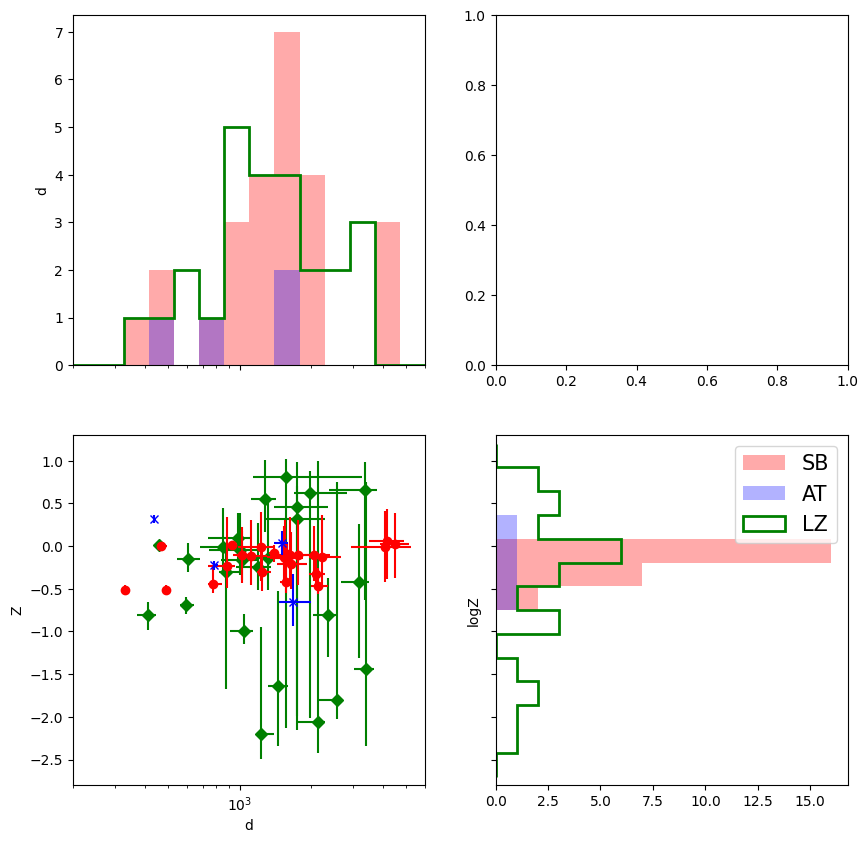

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

Trange = [300, 1800]
Zrange = [-2.8, 1.3]
Drange = [200, 6000]

Tbins = np.linspace(Trange[0]+50, Trange[1]-50, 15)
Zbins = np.linspace(Zrange[0]+0.1, Zrange[1]-0.1, 15)
Dbins = np.logspace(np.log10(Drange[0]+1), np.log10(Drange[1]-1), 15)

ax = axs[0, 0]
ax.hist(SB_data['d50'], bins=Dbins, histtype='bar', color='#FFAAAA', label='SB')
ax.hist(AT_data['d50'], bins=Dbins, histtype='bar', color='b', label='AT', alpha=0.3)
ax.hist(LZ_data['d50'], bins=Dbins, histtype='step', color='g', label='LZ', lw=2)
ax.set_xlim(Drange)
ax.set_xscale('log')
ax.set_xticklabels([])
ax.set_ylabel('d')

ax = axs[1, 1]
ax.hist(SB_data['Z50'], bins=Zbins, histtype='bar', color='#FFAAAA', label='SB', orientation='horizontal')
ax.hist(AT_data['Z50'], bins=Zbins, histtype='bar', color='b', label='AT', alpha=0.3, orientation='horizontal')
ax.hist(LZ_data['Z50'], bins=Zbins, histtype='step', color='g', label='LZ', lw=2, orientation='horizontal')
ax.set_ylim(Zrange)
ax.set_yticklabels([])
ax.set_ylabel('logZ')
ax.legend(loc='upper right', fontsize=15)

ax = axs[1, 0]
ax.errorbar(
    SB_data['d50'], SB_data['Z50'],
    xerr=[SB_data['d50']-SB_data['d16'], SB_data['d84']-SB_data['d50']],
    yerr=[SB_data['Z50']-SB_data['Z16'], SB_data['Z84']-SB_data['Z50']],
    fmt='o', color='r', label='SB', zorder=5
)
ax.errorbar(
    AT_data['d50'], AT_data['Z50'],
    xerr=[AT_data['d50']-AT_data['d16'], AT_data['d84']-AT_data['d50']],
    yerr=[AT_data['Z50']-AT_data['Z16'], AT_data['Z84']-AT_data['Z50']],
    fmt='x', color='b', label='AT', zorder=10
)
ax.errorbar(
    LZ_data['d50'], LZ_data['Z50'],
    xerr=[LZ_data['d50']-LZ_data['d16'], LZ_data['d84']-LZ_data['d50']],
    yerr=[LZ_data['Z50']-LZ_data['Z16'], LZ_data['Z84']-LZ_data['Z50']],
    fmt='D', color='g', label='LZ', zorder=1
)
ax.set_xlim(Drange)
ax.set_ylim(Zrange)
ax.set_xscale('log')
ax.set_xlabel('d')
ax.set_ylabel('Z')

plt.show()
